# Fase 4 — Consolidación, visualización y comunicación de resultados

**Proyecto:** Caracterización temporal de la generación eléctrica de TER CMPC Laja, TER CMPC Pacífico y TER CMPC Santa Fe  
**Período:** enero–agosto de 2026  
**Curso:** Programación para la Ciencia de Datos — MCDI500

---

## Propósito del notebook

Este notebook consolida los desarrollos realizados durante las Fases 1, 2 y 3 del proyecto y los integra en una etapa final orientada al análisis, visualización e interpretación de resultados.

En la **Fase 1** se definieron el problema, la pregunta de investigación y los objetivos. En la **Fase 2** se construyó y validó el proceso reproducible de preparación de datos. En la **Fase 3** se incorporaron algoritmos estructurados y recursivos, mediciones de eficiencia, modularización y principios de Programación Orientada a Objetos (POO).

La **Fase 4** utiliza estos desarrollos para volver a la pregunta de investigación, analizar los patrones temporales identificados y comunicar los principales hallazgos mediante visualizaciones analíticas, manteniendo trazabilidad entre los datos, el código, los resultados y las conclusiones.

## Pregunta de investigación

**¿Qué patrones temporales de generación eléctrica caracterizan a las centrales TER CMPC Laja, TER CMPC Pacífico y TER CMPC Santa Fe durante el período enero–agosto de 2026?**

## Objetivo general

**Analizar los patrones temporales de generación eléctrica de las centrales TER CMPC Laja, TER CMPC Pacífico y TER CMPC Santa Fe durante enero–agosto de 2026, a partir de los datos públicos de Generación Real del Coordinador Eléctrico Nacional, mediante un proceso reproducible y trazable de preparación, validación y análisis de datos.**

## Objetivos específicos

1. **Caracterizar** la distribución de la generación eléctrica de cada central considerando su comportamiento horario, diario y mensual.
2. **Comparar** los patrones temporales de generación entre las tres centrales.
3. **Caracterizar** la frecuencia y distribución temporal de los registros de generación igual a `0 MWh`, sin atribuirles una causa operacional no respaldada por la fuente.
4. **Identificar** regularidades y diferencias temporales relevantes que sirvan de base para las etapas posteriores de análisis e interpretación.

> Las operaciones de carga, transformación, validación y versionamiento se consideran parte de la metodología técnica y no objetivos de investigación.

## 1. Reproducibilidad y dependencias

La Fase 4 se ejecuta utilizando el entorno virtual del proyecto y reutiliza los módulos desarrollados en las fases anteriores.

El objetivo de esta sección es verificar el entorno de ejecución y cargar las dependencias necesarias para integrar el pipeline de preparación, validación, análisis temporal y visualización.

Las mediciones de rendimiento obtenidas en fases anteriores dependen del entorno de ejecución; por ello, las versiones de Python y de las bibliotecas principales se documentan como parte de la trazabilidad y reproducibilidad del proyecto.


In [1]:
import os
import sys
import platform

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Permite importar los módulos propios ubicados en src/
sys.path.append(os.path.abspath(".."))

from src.validacion import validar_dataset_procesado
from src.agregacion_temporal import (
    AgregacionHoraria,
    AgregacionDiaria,
    AgregacionMensual,
    AgregacionPorDiaSemana,
    CaracterizadorTemporal,
)

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Sistema: {platform.system()} {platform.release()}")

Python: 3.14.3
pandas: 3.0.5
NumPy: 2.5.3
Sistema: Windows 11


## 2. Integración del dataset preparado y validado

La Fase 4 utiliza como entrada el dataset procesado generado y validado en las fases anteriores. De esta manera, se mantiene la continuidad metodológica del proyecto y se evita duplicar operaciones de preparación ya verificadas.

La unidad de análisis corresponde a **central + fecha + hora**, con la generación eléctrica expresada en MWh.

Antes de realizar las visualizaciones y la interpretación de resultados, se verifica nuevamente la estructura del dataset para asegurar que la información utilizada en F4 sea consistente con los resultados obtenidos en F2 y F3.

In [2]:
# Ruta al dataset procesado en F2 y utilizado en F3
ruta_datos = "../data/processed/dataset_cen_centrales_cmpc_ene_ago_2026.csv"

# Carga del dataset consolidado
df = pd.read_csv(ruta_datos)

# Conversión de Fecha para análisis temporal
df["Fecha"] = pd.to_datetime(df["Fecha"])

print(f"Filas: {len(df):,}")
print(f"Columnas: {df.shape[1]}")
print(f"Fecha inicial: {df['Fecha'].min().date()}")
print(f"Fecha final: {df['Fecha'].max().date()}")
print(f"Centrales: {df['Central'].nunique()}")

df.head()

Filas: 17,496
Columnas: 13
Fecha inicial: 2026-01-01
Fecha final: 2026-08-31
Centrales: 3


,ID_Observacion,Año,Mes,Llave,Central,Coordinado,Grupo_Reporte,Tipo,Subtipo,Fecha,Dia_Semana,Hora,Generacion_MWh
0,TER_CMPC_LAJA_20260101_H01,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-01,Jueves,1,1.1
1,TER_CMPC_LAJA_20260101_H02,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-01,Jueves,2,11.4
2,TER_CMPC_LAJA_20260101_H03,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-01,Jueves,3,10.3
3,TER_CMPC_LAJA_20260101_H04,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-01,Jueves,4,6.9
4,TER_CMPC_LAJA_20260101_H05,2026,Ene,CMPC Laja,TER CMPC LAJA,BIOENERGÍAS FORESTALES SPA,TER CMPC LAJA,Termoeléctricas,Biomasa,2026-01-01,Jueves,5,8.4


## 3. Verificación final de calidad y consistencia

Antes de iniciar el análisis exploratorio y la construcción de visualizaciones, se realiza una verificación final del dataset consolidado.

Esta etapa permite confirmar que la información utilizada en F4 mantiene las condiciones de calidad establecidas en las fases anteriores: ausencia de valores faltantes, identificadores únicos, ausencia de valores negativos de generación y granularidad de 24 observaciones horarias por combinación central-fecha.

Esta verificación actúa como control de integración entre las fases del proyecto y permite asegurar que las visualizaciones posteriores se construyan sobre el mismo conjunto de datos validado.

In [3]:
# Verificaciones básicas del dataset utilizado en F4

print("=== VERIFICACIÓN DEL DATASET F4 ===")

print(f"Observaciones: {len(df):,}")
print(f"Columnas: {df.shape[1]}")
print(f"Valores nulos: {df.isna().sum().sum()}")
print(f"Duplicados exactos: {df.duplicated().sum()}")
print(f"ID duplicados: {df['ID_Observacion'].duplicated().sum()}")
print(f"Valores negativos: {(df['Generacion_MWh'] < 0).sum()}")
print(f"Registros iguales a 0 MWh: {(df['Generacion_MWh'] == 0).sum():,}")

# Comprobación de granularidad central-fecha
granularidad = (
    df.groupby(["Central", "Fecha"])
      .size()
)

print(f"Combinaciones central-fecha: {len(granularidad):,}")
print(f"Mínimo de horas por combinación: {granularidad.min()}")
print(f"Máximo de horas por combinación: {granularidad.max()}")

# Validación final
assert len(df) == 17496
assert df.shape[1] == 13
assert df.isna().sum().sum() == 0
assert df.duplicated().sum() == 0
assert df["ID_Observacion"].duplicated().sum() == 0
assert (df["Generacion_MWh"] < 0).sum() == 0
assert granularidad.min() == 24
assert granularidad.max() == 24

print("\n✓ Dataset validado correctamente para F4.")

=== VERIFICACIÓN DEL DATASET F4 ===
Observaciones: 17,496
Columnas: 13
Valores nulos: 0
Duplicados exactos: 0
ID duplicados: 0
Valores negativos: 0
Registros iguales a 0 MWh: 4,438
Combinaciones central-fecha: 729
Mínimo de horas por combinación: 24
Máximo de horas por combinación: 24

✓ Dataset validado correctamente para F4.


## 4. Objetivo específico 1 — Caracterización temporal de la generación

**Objetivo:** Caracterizar la distribución de la generación eléctrica de cada central considerando su comportamiento horario, diario y mensual.

Para responder este objetivo se analiza la generación en tres escalas temporales complementarias:

- **Horaria:** permite identificar regularidades a lo largo de las 24 horas del día.
- **Diaria:** permite observar la evolución de la generación durante los 243 días del período analizado.
- **Mensual:** permite resumir y comparar el comportamiento entre enero y agosto de 2026.

Las agregaciones se realizan por central, manteniendo separadas las tres unidades de generación analizadas.

In [4]:
# Estrategias temporales desarrolladas en F3

estrategia_horaria = AgregacionHoraria()
estrategia_diaria = AgregacionDiaria()
estrategia_mensual = AgregacionMensual()
estrategia_dia_semana = AgregacionPorDiaSemana()

# Caracterizadores que aplican cada estrategia
caracterizador_horario = CaracterizadorTemporal(estrategia_horaria)
caracterizador_diario = CaracterizadorTemporal(estrategia_diaria)
caracterizador_mensual = CaracterizadorTemporal(estrategia_mensual)
caracterizador_dia_semana = CaracterizadorTemporal(estrategia_dia_semana)

print("✓ Estrategias temporales de F3 cargadas correctamente.")

✓ Estrategias temporales de F3 cargadas correctamente.


In [5]:
print("Métodos disponibles en CaracterizadorTemporal:")
print([
    metodo
    for metodo in dir(caracterizador_horario)
    if not metodo.startswith("_")
])

Métodos disponibles en CaracterizadorTemporal:
['caracterizar', 'estrategia']


In [6]:
# Aplicación de las estrategias temporales desarrolladas en F3

resultado_horario = caracterizador_horario.caracterizar(df)
resultado_diario = caracterizador_diario.caracterizar(df)
resultado_mensual = caracterizador_mensual.caracterizar(df)
resultado_dia_semana = caracterizador_dia_semana.caracterizar(df)

print("=== RESULTADOS DE LAS AGREGACIONES TEMPORALES ===")
print(f"Agregación horaria: {resultado_horario.shape}")
print(f"Agregación diaria: {resultado_diario.shape}")
print(f"Agregación mensual: {resultado_mensual.shape}")
print(f"Agregación por día de semana: {resultado_dia_semana.shape}")

=== RESULTADOS DE LAS AGREGACIONES TEMPORALES ===
Agregación horaria: (72,)
Agregación diaria: (729,)
Agregación mensual: (24,)
Agregación por día de semana: (21,)


In [7]:
print("=== AGREGACIÓN HORARIA ===")
display(resultado_horario.head())

print("\n=== AGREGACIÓN DIARIA ===")
display(resultado_diario.head())

print("\n=== AGREGACIÓN MENSUAL ===")
display(resultado_mensual.head())

print("\n=== AGREGACIÓN POR DÍA DE SEMANA ===")
display(resultado_dia_semana.head())

=== AGREGACIÓN HORARIA ===


Central        Hora
TER CMPC LAJA  1       3.428395
               2       3.444033
               3       3.560494
               4       3.594650
               5       3.544856
Name: Generacion_MWh_promedio, dtype: float64


=== AGREGACIÓN DIARIA ===


Central        Fecha     
TER CMPC LAJA  2026-01-01    165.7
               2026-01-02    275.8
               2026-01-03    347.9
               2026-01-04    313.1
               2026-01-05    380.8
Name: Generacion_MWh_total, dtype: float64


=== AGREGACIÓN MENSUAL ===


Central        Mes
TER CMPC LAJA  Abr    1560.2
               Ago     298.0
               Ene    5662.2
               Feb    4540.3
               Jul     448.6
Name: Generacion_MWh_total, dtype: float64


=== AGREGACIÓN POR DÍA DE SEMANA ===


Central        Dia_Semana
TER CMPC LAJA  Domingo       2.528214
               Jueves        3.776071
               Lunes         2.966667
               Martes        3.574632
               Miércoles     3.987500
Name: Generacion_MWh_promedio, dtype: float64

### 4.1 Estadísticas descriptivas por central

Como punto de partida, se resumen las principales medidas descriptivas de la generación eléctrica de cada central. Estas estadísticas permiten contextualizar los análisis temporales posteriores y reconocer diferencias generales en nivel, dispersión y presencia de registros iguales a 0 MWh.

Los valores iguales a 0 MWh se mantienen como observaciones válidas del dataset. Su presencia se describe cuantitativamente, sin atribuir una causa operacional que no esté respaldada por la fuente de datos.

In [8]:
# Estadísticas descriptivas de generación por central

resumen_centrales = (
    df.groupby("Central")["Generacion_MWh"]
      .agg(
          Observaciones="count",
          Media_MWh="mean",
          Mediana_MWh="median",
          Minimo_MWh="min",
          Maximo_MWh="max",
          Desv_Estandar_MWh="std"
      )
      .round(2)
)

# Cantidad y porcentaje de registros iguales a 0 MWh
ceros_centrales = (
    df.assign(Es_Cero=df["Generacion_MWh"].eq(0))
      .groupby("Central")["Es_Cero"]
      .agg(Registros_Cero="sum", Total="count")
)

ceros_centrales["Porcentaje_Cero"] = (
    ceros_centrales["Registros_Cero"]
    / ceros_centrales["Total"]
    * 100
).round(2)

# Integración de ambos resultados
resumen_centrales = resumen_centrales.join(
    ceros_centrales[["Registros_Cero", "Porcentaje_Cero"]]
)

display(resumen_centrales)

,Observaciones,Media_MWh,Mediana_MWh,Minimo_MWh,Maximo_MWh,Desv_Estandar_MWh,Registros_Cero,Porcentaje_Cero
Central,,,,,,,,
TER CMPC LAJA,5832,3.45,0.0,0.0,27.3,4.94,3193,54.75
TER CMPC PACIFICO,5832,16.19,17.8,0.0,33.2,7.92,371,6.36
TER CMPC SANTA FE,5832,5.14,5.7,0.0,17.9,3.17,874,14.99


In [9]:
print("Tipo de resultado:")
print(type(resultado_horario))

print("\nNombre de la serie:")
print(resultado_horario.name)

print("\nNombres de los índices:")
print(resultado_horario.index.names)

print("\nPrimeros 10 resultados:")
display(resultado_horario.head(10))

Tipo de resultado:
<class 'pandas.Series'>

Nombre de la serie:
Generacion_MWh_promedio

Nombres de los índices:
['Central', 'Hora']

Primeros 10 resultados:


Central        Hora
TER CMPC LAJA  1       3.428395
               2       3.444033
               3       3.560494
               4       3.594650
               5       3.544856
               6       3.294239
               7       3.326749
               8       3.397119
               9       3.269547
               10      3.267078
Name: Generacion_MWh_promedio, dtype: float64

In [10]:
# Conversión del resultado horario de F3 a DataFrame
perfil_horario = resultado_horario.reset_index()

print("Columnas disponibles:")
print(perfil_horario.columns.tolist())

display(perfil_horario.head(10))

Columnas disponibles:
['Central', 'Hora', 'Generacion_MWh_promedio']


,Central,Hora,Generacion_MWh_promedio
0,TER CMPC LAJA,1,3.428395
1,TER CMPC LAJA,2,3.444033
2,TER CMPC LAJA,3,3.560494
3,TER CMPC LAJA,4,3.594650
4,TER CMPC LAJA,5,3.544856
5,TER CMPC LAJA,6,3.294239
6,TER CMPC LAJA,7,3.326749
7,TER CMPC LAJA,8,3.397119
8,TER CMPC LAJA,9,3.269547
9,TER CMPC LAJA,10,3.267078


### 4.2 Perfil horario de generación

Se analiza el comportamiento promedio de la generación eléctrica a lo largo de las 24 horas del día para cada central.

La agregación horaria permite comparar la forma del perfil diario de TER CMPC Laja, TER CMPC Pacífico y TER CMPC Santa Fe, identificando regularidades y diferencias en su comportamiento temporal durante el período enero–agosto de 2026.

Variable utilizada en el eje Y: Generacion_MWh_promedio


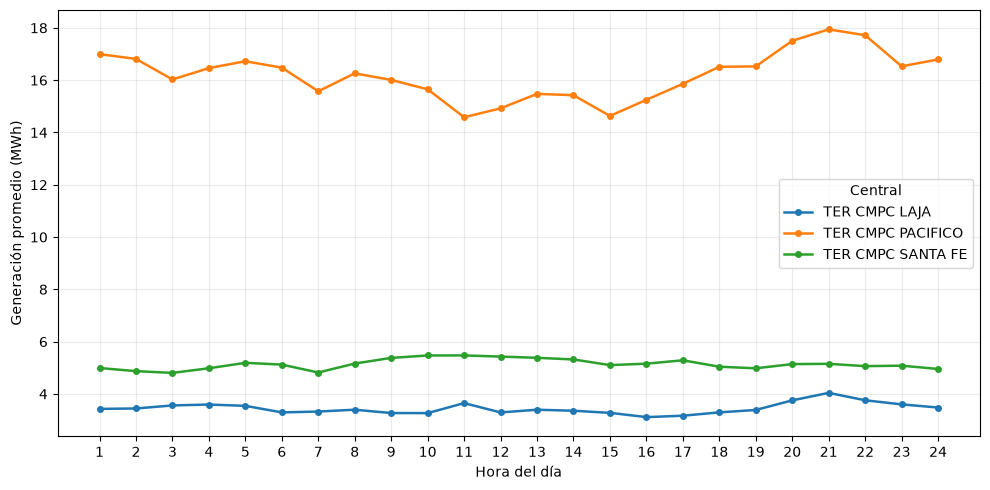

In [11]:
# Preparación del resultado horario para visualización
perfil_horario = resultado_horario.reset_index()

# La última columna corresponde al valor calculado
# por la estrategia de agregación horaria de F3
columna_valor = perfil_horario.columns[-1]

print(f"Variable utilizada en el eje Y: {columna_valor}")

# Construcción de la figura
fig, ax = plt.subplots(figsize=(10, 5))

for central, datos in perfil_horario.groupby("Central"):
    datos = datos.sort_values("Hora")

    ax.plot(
        datos["Hora"],
        datos[columna_valor],
        marker="o",
        markersize=4,
        linewidth=1.8,
        label=central
    )

ax.set_xlabel("Hora del día")
ax.set_ylabel("Generación promedio (MWh)")
ax.set_xticks(range(1, 25))
ax.grid(alpha=0.25)
ax.legend(title="Central")

plt.tight_layout()
plt.show()

### 4.3 Evolución diaria y mensual

Para completar el objetivo específico 1, se examina la generación en escalas diaria y mensual. La agregación diaria conserva la evolución de los 243 días del período, mientras que la agregación mensual resume el comportamiento de enero a agosto de 2026.


In [12]:
# Conversión de las agregaciones de F3 a DataFrame
perfil_diario = resultado_diario.reset_index()
perfil_mensual = resultado_mensual.reset_index()

# Orden cronológico de los meses
orden_meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago"]
perfil_mensual["Mes"] = pd.Categorical(
    perfil_mensual["Mes"], categories=orden_meses, ordered=True
)
perfil_mensual = perfil_mensual.sort_values(["Central", "Mes"])

print("Resumen diario:")
display(perfil_diario.head())

print("\nResumen mensual:")
display(perfil_mensual)


Resumen diario:


,Central,Fecha,Generacion_MWh_total
0,TER CMPC LAJA,2026-01-01,165.7
1,TER CMPC LAJA,2026-01-02,275.8
2,TER CMPC LAJA,2026-01-03,347.9
3,TER CMPC LAJA,2026-01-04,313.1
4,TER CMPC LAJA,2026-01-05,380.8



Resumen mensual:


,Central,Mes,Generacion_MWh_total
2,TER CMPC LAJA,Ene,5662.2
3,TER CMPC LAJA,Feb,4540.3
6,TER CMPC LAJA,Mar,3695.0
0,TER CMPC LAJA,Abr,1560.2
7,TER CMPC LAJA,May,1276.2
5,TER CMPC LAJA,Jun,2615.1
4,TER CMPC LAJA,Jul,448.6
1,TER CMPC LAJA,Ago,298.0
10,TER CMPC PACIFICO,Ene,12840.9
11,TER CMPC PACIFICO,Feb,9516.6


## 5. Objetivo específico 2 — Comparación de patrones temporales

**Objetivo:** Comparar los patrones temporales de generación entre las tres centrales.

La comparación se realiza utilizando escalas temporales comunes. El perfil horario permite contrastar la forma del comportamiento diario y la evolución mensual permite observar cambios a lo largo del período completo.


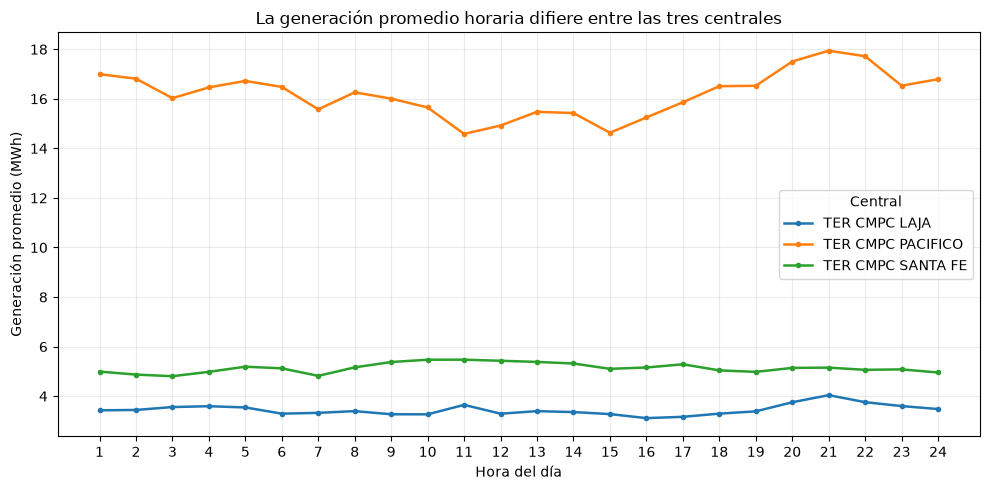

In [13]:
# FIGURA 1 — Perfil horario promedio
perfil_horario = resultado_horario.reset_index()
columna_horaria = resultado_horario.name

fig, ax = plt.subplots(figsize=(10, 5))
for central, datos in perfil_horario.groupby("Central"):
    datos = datos.sort_values("Hora")
    ax.plot(
        datos["Hora"], datos[columna_horaria],
        marker="o", markersize=3, linewidth=1.8, label=central
    )

ax.set_title("La generación promedio horaria difiere entre las tres centrales")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Generación promedio (MWh)")
ax.set_xticks(range(1, 25))
ax.grid(alpha=0.25)
ax.legend(title="Central")
plt.tight_layout()
plt.show()


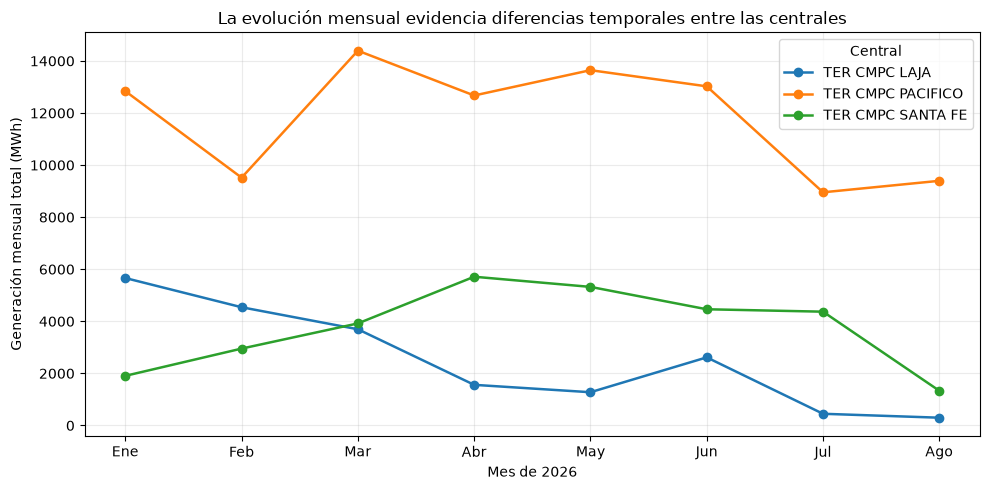

In [14]:
# FIGURA 2 — Evolución mensual de la generación total
columna_mensual = resultado_mensual.name

fig, ax = plt.subplots(figsize=(10, 5))
for central, datos in perfil_mensual.groupby("Central", observed=True):
    datos = datos.sort_values("Mes")
    ax.plot(
        datos["Mes"].astype(str), datos[columna_mensual],
        marker="o", linewidth=1.8, label=central
    )

ax.set_title("La evolución mensual evidencia diferencias temporales entre las centrales")
ax.set_xlabel("Mes de 2026")
ax.set_ylabel("Generación mensual total (MWh)")
ax.grid(alpha=0.25)
ax.legend(title="Central")
plt.tight_layout()
plt.show()


## 6. Objetivo específico 3 — Frecuencia y distribución temporal de registros de 0 MWh

**Objetivo:** Caracterizar la frecuencia y distribución temporal de los registros de generación igual a 0 MWh, sin atribuirles una causa operacional no respaldada por la fuente.

Los registros de 0 MWh se conservan como observaciones válidas. El análisis siguiente cuantifica su presencia por central y mes, permitiendo estudiar su distribución temporal sin interpretar causalidad operacional.


In [15]:
# Porcentaje mensual de registros iguales a 0 MWh por central
ceros_mensuales = (
    df.assign(Es_Cero=df["Generacion_MWh"].eq(0))
      .groupby(["Central", "Mes"], observed=True)["Es_Cero"]
      .agg(Registros_Cero="sum", Total_Registros="count")
      .reset_index()
)

ceros_mensuales["Porcentaje_Cero"] = (
    ceros_mensuales["Registros_Cero"] /
    ceros_mensuales["Total_Registros"] * 100
).round(2)

ceros_mensuales["Mes"] = pd.Categorical(
    ceros_mensuales["Mes"], categories=orden_meses, ordered=True
)
ceros_mensuales = ceros_mensuales.sort_values(["Central", "Mes"])

display(ceros_mensuales)


,Central,Mes,Registros_Cero,Total_Registros,Porcentaje_Cero
2,TER CMPC LAJA,Ene,148,744,19.89
3,TER CMPC LAJA,Feb,103,672,15.33
6,TER CMPC LAJA,Mar,274,744,36.83
0,TER CMPC LAJA,Abr,539,720,74.86
7,TER CMPC LAJA,May,565,744,75.94
5,TER CMPC LAJA,Jun,220,720,30.56
4,TER CMPC LAJA,Jul,659,744,88.58
1,TER CMPC LAJA,Ago,685,744,92.07
10,TER CMPC PACIFICO,Ene,80,744,10.75
11,TER CMPC PACIFICO,Feb,62,672,9.23


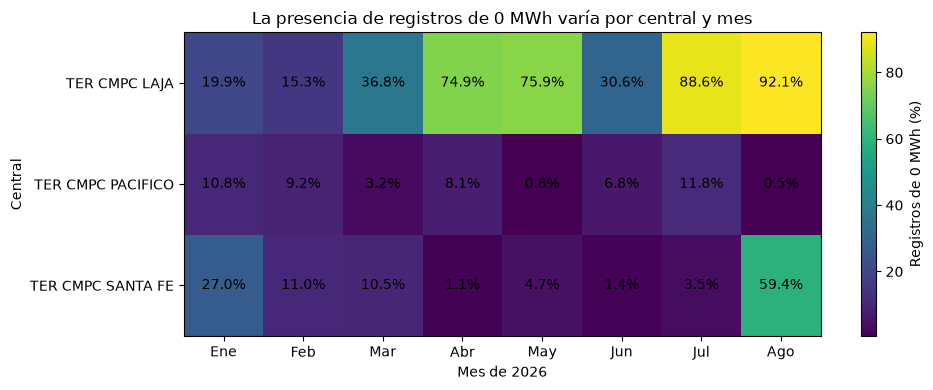

In [16]:
# FIGURA 3 — Distribución mensual de registros de 0 MWh
matriz_ceros = (
    ceros_mensuales
    .pivot(index="Central", columns="Mes", values="Porcentaje_Cero")
    .reindex(columns=orden_meses)
)

fig, ax = plt.subplots(figsize=(10, 4))
imagen = ax.imshow(matriz_ceros.values, aspect="auto")

ax.set_title("La presencia de registros de 0 MWh varía por central y mes")
ax.set_xlabel("Mes de 2026")
ax.set_ylabel("Central")
ax.set_xticks(range(len(matriz_ceros.columns)))
ax.set_xticklabels(matriz_ceros.columns)
ax.set_yticks(range(len(matriz_ceros.index)))
ax.set_yticklabels(matriz_ceros.index)

for i in range(matriz_ceros.shape[0]):
    for j in range(matriz_ceros.shape[1]):
        valor = matriz_ceros.iloc[i, j]
        ax.text(j, i, f"{valor:.1f}%", ha="center", va="center")

barra = fig.colorbar(imagen, ax=ax)
barra.set_label("Registros de 0 MWh (%)")
plt.tight_layout()
plt.show()


## 7. Objetivo específico 4 — Regularidades y diferencias temporales

**Objetivo:** Identificar regularidades y diferencias temporales relevantes que sirvan de base para las etapas posteriores de análisis e interpretación.

La síntesis integra las visualizaciones anteriores. Se consideran conjuntamente el perfil horario, la evolución mensual y la distribución temporal de los registros de 0 MWh. Esta lectura permite identificar diferencias entre centrales sin atribuir causas operacionales que no estén contenidas en la fuente de datos.


In [17]:
# Tabla de síntesis cuantitativa
sintesis = resumen_centrales.copy()
sintesis["Rango_MWh"] = (
    sintesis["Maximo_MWh"] - sintesis["Minimo_MWh"]
).round(2)

sintesis = sintesis[[
    "Media_MWh", "Mediana_MWh", "Desv_Estandar_MWh",
    "Registros_Cero", "Porcentaje_Cero", "Rango_MWh"
]]

display(sintesis)


,Media_MWh,Mediana_MWh,Desv_Estandar_MWh,Registros_Cero,Porcentaje_Cero,Rango_MWh
Central,,,,,,
TER CMPC LAJA,3.45,0.0,4.94,3193,54.75,27.3
TER CMPC PACIFICO,16.19,17.8,7.92,371,6.36,33.2
TER CMPC SANTA FE,5.14,5.7,3.17,874,14.99,17.9


## 8. Resultados principales

El análisis confirma que las tres centrales presentan comportamientos temporales diferenciados durante enero–agosto de 2026. En términos globales, TER CMPC Pacífico registra la mayor generación media horaria del conjunto analizado, seguida por TER CMPC Santa Fe y TER CMPC Laja.

Los registros de 0 MWh no se distribuyen de manera uniforme entre las centrales. TER CMPC Laja concentra **3.193 registros (54,75 %)**, TER CMPC Santa Fe **874 (14,99 %)** y TER CMPC Pacífico **371 (6,36 %)**. La distribución mensual complementa esta comparación mostrando cómo estos registros se distribuyen durante el período.

Estos resultados describen patrones observados en los datos públicos analizados y no permiten, por sí solos, establecer las causas operacionales de las variaciones o de los registros de 0 MWh.


## 9. Discusión y limitaciones

La estructura horaria del dataset permite comparar las centrales bajo una granularidad homogénea de 24 observaciones por central y fecha. La combinación de escalas horaria, diaria y mensual entrega una visión complementaria del comportamiento temporal y evita depender de un único nivel de agregación.

La principal limitación interpretativa es que el conjunto de datos utilizado contiene registros de generación eléctrica, pero no incorpora antecedentes suficientes para determinar las causas de cada variación o de los valores iguales a 0 MWh. Por esta razón, el análisis se mantiene en un nivel descriptivo y comparativo.

Además, las conclusiones se restringen al período enero–agosto de 2026 y a las tres centrales seleccionadas; por tanto, no deben extrapolarse automáticamente a otros períodos o instalaciones.


## 10. Conclusiones

La pregunta de investigación se abordó mediante un flujo reproducible que integra la definición del problema de F1, la preparación y validación de datos de F2, y las estrategias algorítmicas y de diseño desarrolladas en F3.

Durante enero–agosto de 2026 se observan diferencias entre TER CMPC Laja, TER CMPC Pacífico y TER CMPC Santa Fe tanto en sus niveles de generación como en la frecuencia de registros de 0 MWh. El análisis en distintas escalas temporales permite caracterizar estas diferencias sin atribuir explicaciones operacionales no respaldadas por la fuente.

La integración final demuestra que los módulos desarrollados previamente pueden reutilizarse para producir resultados, visualizaciones y evidencia trazable orientada a responder los objetivos de investigación.


## 11. Trazabilidad F1 → F4

| Fase | Aporte al proyecto |
|---|---|
| **F1** | Definición del problema, pregunta de investigación, objetivos y ecosistema reproducible. |
| **F2** | Preparación, transformación y validación del dataset de Generación Real. |
| **F3** | Núcleo algorítmico, comparación de eficiencia, recursividad, modularización, POO y patrón Strategy. |
| **F4** | Integración de resultados, análisis temporal, visualizaciones, interpretación, discusión y conclusiones. |

Esta secuencia mantiene la trazabilidad entre el problema planteado, los datos procesados, el código desarrollado y los resultados comunicados.


## 12. Referencias y fuentes

- Coordinador Eléctrico Nacional. **Generación Real**. Fuente pública utilizada para la obtención de los datos del proyecto.
- Coordinador Eléctrico Nacional. **Diccionario de Datos Web SIP (B43-DIN-04)**. Documento técnico utilizado para contextualizar la estructura de los datos.
- Documentación oficial de **Python**.
- Documentación oficial de **pandas**.
- Documentación oficial de **Matplotlib**.

> En el informe final, estas referencias deben presentarse en formato APA 7 y complementarse con las fuentes docentes y académicas exigidas por la rúbrica.
